# Lab 13 — Multi-agent crew: Triager → Extractor → Reviewer → Fallback

Use case: support extraction for Ukrainian admin/service messages.
This notebook compares a single-agent baseline against a controlled multi-agent workflow.

In [1]:
%pip install -q pandas jsonschema matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\maia1\data\politiekh\masters\nlp\.venv\Scripts\python.exe -m pip install --upgrade pip


In [2]:
from __future__ import annotations
import json, sys
from collections import Counter
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
project_root = Path.cwd()
if not (project_root / "project_lab13").exists():
    for p in [project_root, *project_root.parents]:
        if (p / "project_lab13").exists():
            project_root = p
            break
lab_root = project_root / "project_lab13"
src_root = lab_root / "src"
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))
from agents import SCHEMA, TriagerAgent, ExtractorAgent
from reviewer import ReviewerAgent
from fallback import FallbackAgent
from crew_workflow import CrewWorkflow
from eval_crew import load_cases, run_single_agent, run_crew, compute_metrics, compare_output
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 160)

## 1. Test cases

In [3]:
cases = load_cases(lab_root / "data" / "sample" / "test_cases_lab13.jsonl")
print("test_cases =", len(cases))
pd.DataFrame(cases)[["case_id", "expected_route", "needs_fallback", "tags"]]

test_cases = 12


,case_id,expected_route,needs_fallback,tags
0,case_001_simple_compensation,compensation_route,False,[simple]
1,case_002_document_cnap,document_route,False,"[simple, document]"
2,case_003_ambiguous_service,access_route,True,"[ambiguous entity, manual review]"
3,case_004_relative_date,payment_route,False,[relative date]
4,case_005_hallucination_prone,compensation_route,True,[hallucination-prone case]
5,case_006_noisy_typos,access_route,True,"[noisy text / typos, repair helps]"
6,case_007_passport_queue,passport_route,False,[simple]
7,case_008_notary_date,inheritance_route,False,[simple]
8,case_009_repair_needed_missing_field,document_route,True,"[repair helps, missing required field]"
9,case_010_manual_review_conflict,access_route,True,"[repair fails and manual review is needed, ambiguous case]"


## 2. Agent role definitions

In [4]:
role_notes = {
    "Triager": "Routes the input, selects the schema route, marks difficulty and special handling.",
    "Extractor": "Builds the structured extraction according to the route.",
    "Reviewer": "Checks schema validity, consistency with input, hallucinations, and missing fields.",
    "RepairFallback": "Repairs predictable problems or escalates to manual review."
}
role_notes

{'Triager': 'Routes the input, selects the schema route, marks difficulty and special handling.',
 'Extractor': 'Builds the structured extraction according to the route.',
 'Reviewer': 'Checks schema validity, consistency with input, hallucinations, and missing fields.',
 'RepairFallback': 'Repairs predictable problems or escalates to manual review.'}

## 3. Delegation rules

In [5]:
delegation_rules = [
    "Triager always runs first.",
    "If route contains document signals -> document_route.",
    "If route contains amount/payment signals -> payment_route.",
    "If route contains passport signals -> passport_route.",
    "Reviewer always checks extractor output.",
    "If reviewer verdict = repair_needed -> one fallback repair attempt.",
    "If ambiguity remains after review -> manual_review.",
]
for rule in delegation_rules:
    print('-', rule)

- Triager always runs first.
- If route contains document signals -> document_route.
- If route contains amount/payment signals -> payment_route.
- If route contains passport signals -> passport_route.
- Reviewer always checks extractor output.
- If reviewer verdict = repair_needed -> one fallback repair attempt.
- If ambiguity remains after review -> manual_review.


## 4. Single-agent baseline

In [6]:
baseline_runs = [run_single_agent(case) for case in cases]
baseline_df = pd.DataFrame([
    {
        "case_id": run["case_id"],
        "schema_valid": run["schema_valid"],
        "semantic_ok": run["semantic"]["semantic_ok"],
        "issues": run["semantic"]["issues"],
    }
    for run in baseline_runs
])
baseline_df

,case_id,schema_valid,semantic_ok,issues
0,case_001_simple_compensation,True,False,"[services_mentioned: mismatch, issue_type: mismatch]"
1,case_002_document_cnap,True,True,[]
2,case_003_ambiguous_service,True,False,"[primary_service: mismatch, services_mentioned: mismatch]"
3,case_004_relative_date,True,False,[date_text: mismatch]
4,case_005_hallucination_prone,True,False,[primary_service: mismatch]
5,case_006_noisy_typos,False,False,[invalid JSON]
6,case_007_passport_queue,True,False,[issue_type: mismatch]
7,case_008_notary_date,True,True,[]
8,case_009_repair_needed_missing_field,False,False,[invalid JSON]
9,case_010_manual_review_conflict,True,False,"[primary_service: mismatch, services_mentioned: mismatch, issue_type: mismatch, document_type: hallucinated, location_text: hallucinated]"


## 5. Multi-agent crew workflow

In [7]:
crew_runs = run_crew(cases)
crew_df = pd.DataFrame([
    {
        "case_id": run["case_id"],
        "route": run["triager_output"]["route"],
        "reviewer_verdict": run["reviewer_output"]["verdict"],
        "fallback_triggered": run["fallback_triggered"],
        "status": run["status"],
        "schema_valid": run["schema_valid"],
        "agents_called": run["agents_called"],
    }
    for run in crew_runs
])
crew_df

,case_id,route,reviewer_verdict,fallback_triggered,status,schema_valid,agents_called
0,case_001_simple_compensation,compensation_route,accept,False,accepted,True,3
1,case_002_document_cnap,document_route,manual_review,True,manual_review,True,4
2,case_003_ambiguous_service,access_route,accept,False,accepted,True,3
3,case_004_relative_date,payment_route,accept,False,accepted,True,3
4,case_005_hallucination_prone,compensation_route,repair_needed,True,accepted_after_repair,True,4
5,case_006_noisy_typos,access_route,repair_needed,True,accepted_after_repair,True,4
6,case_007_passport_queue,passport_route,accept,False,accepted,True,3
7,case_008_notary_date,inheritance_route,accept,False,accepted,True,3
8,case_009_repair_needed_missing_field,document_route,repair_needed,True,accepted_after_repair,True,4
9,case_010_manual_review_conflict,document_route,manual_review,True,manual_review,True,4


## 6. Reviewer consistency checks

In [8]:
review_checks = [
    'valid JSON / schema',
    'required fields',
    'consistency with input',
    'hallucinated values',
    'contradictory service choice',
    'relative-date uncertainty',
]
review_checks

['valid JSON / schema',
 'required fields',
 'consistency with input',
 'hallucinated values',
 'contradictory service choice',
 'relative-date uncertainty']

## 7. Fallback logic

In [9]:
fallback_rules = {
    'invalid JSON': 'rule-based repair',
    'missing document_type on document_route': 'repair document_type',
    'hallucinated service or location': 'drop hallucinated field / set unknown',
    'persistent ambiguity': 'manual_review',
}
fallback_rules

{'invalid JSON': 'rule-based repair',
 'missing document_type on document_route': 'repair document_type',
 'hallucinated service or location': 'drop hallucinated field / set unknown',
 'persistent ambiguity': 'manual_review'}

## 8. Run 10+ test cases

In [10]:
metrics = compute_metrics(cases, baseline_runs, crew_runs)
metrics

{'valid_final_output_rate': 0.8333333333333334,
 'reviewer_catch_rate': 1.0,
 'fallback_activation_rate': 0.5,
 'fallback_success_rate': 0.6666666666666666,
 'manual_review_rate': 0.16666666666666666,
 'average_agents_called_per_case': 3.5,
 'schema_valid_rate': 1.0,
 'baseline_schema_valid_rate': 0.8333333333333334,
 'baseline_semantic_success_rate': 0.25,
 'crew_semantic_success_rate': 0.5}

## 9. Crew logs

In [11]:
logs_path = lab_root / "docs" / "crew_logs_lab13.jsonl"
with logs_path.open('w', encoding='utf-8') as f:
    for run in crew_runs:
        f.write(json.dumps(run, ensure_ascii=False) + "\n")
print(logs_path)
print(logs_path.read_text(encoding='utf-8').splitlines()[0])

C:\Users\maia1\data\politiekh\masters\nlp\project_lab13\docs\crew_logs_lab13.jsonl
{"case_id": "case_001_simple_compensation", "input": "Через Дію подав заяву на єВідновлення. Коли надійдуть кошти?", "triager_output": {"task_type": "support_extraction", "route": "compensation_route", "expected_fields": ["primary_service", "services_mentioned", "issue_type", "document_type", "amounts_uah", "date_text", "location_text"], "difficulty": "low", "special_handling": [], "notes": "route=compensation_route; special=['none']"}, "extractor_output": {"primary_service": "єВідновлення", "services_mentioned": ["єВідновлення"], "issue_type": "application_submission", "document_type": "заява", "amounts_uah": [], "date_text": null, "location_text": null}, "reviewer_output": {"verdict": "accept", "valid_json": true, "schema_ok": true, "consistency_ok": true, "issues": [], "recommended_action": "none"}, "fallback_triggered": false, "fallback_output": null, "final_output": {"primary_service": "єВідновлення

## 10. Metrics

In [12]:
comparison_df = pd.DataFrame([
    {"system": "single_agent", "schema_valid_rate": metrics["baseline_schema_valid_rate"], "semantic_success_rate": metrics["baseline_semantic_success_rate"]},
    {"system": "crew", "schema_valid_rate": metrics["schema_valid_rate"], "semantic_success_rate": metrics["crew_semantic_success_rate"]},
])
comparison_df

,system,schema_valid_rate,semantic_success_rate
0,single_agent,0.833333,0.25
1,crew,1.000000,0.50


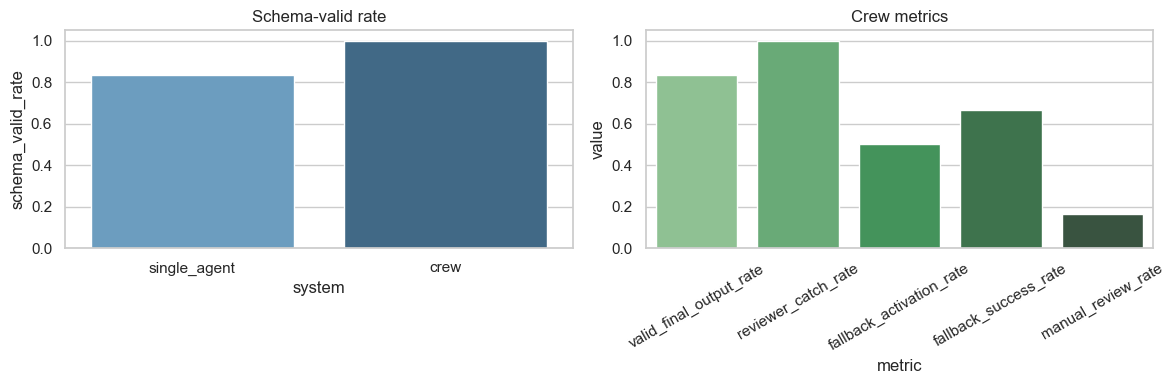

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=comparison_df, x='system', y='schema_valid_rate', hue='system', legend=False, palette='Blues_d', ax=axes[0])
axes[0].set_ylim(0, 1.05)
axes[0].set_title('Schema-valid rate')
metrics_df = pd.DataFrame({
    'metric': ['valid_final_output_rate', 'reviewer_catch_rate', 'fallback_activation_rate', 'fallback_success_rate', 'manual_review_rate'],
    'value': [metrics['valid_final_output_rate'], metrics['reviewer_catch_rate'], metrics['fallback_activation_rate'], metrics['fallback_success_rate'], metrics['manual_review_rate']],
})
sns.barplot(data=metrics_df, x='metric', y='value', hue='metric', legend=False, palette='Greens_d', ax=axes[1])
axes[1].set_ylim(0, 1.05)
axes[1].tick_params(axis='x', rotation=30)
axes[1].set_title('Crew metrics')
plt.tight_layout()
plt.show()

## 11. Error analysis

In [14]:
case_lookup = {case['case_id']: case for case in cases}
problem_rows = []
for run in crew_runs:
    expected = case_lookup[run['case_id']]['expected']
    semantic = compare_output(expected, run['final_output'])
    categories = []
    if run['triager_output']['route'] != case_lookup[run['case_id']]['expected_route']:
        categories.append('wrong triage route')
    if run['reviewer_output']['verdict'] == 'manual_review':
        categories.append('manual review needed')
    if run['fallback_triggered'] and run['status'] == 'accepted_after_repair':
        categories.append('repair helps')
    if semantic['hallucinated']:
        categories.append('extractor hallucinated field')
    if semantic['missing_required']:
        categories.append('extractor missing field')
    if run['reviewer_output']['issues'] and run['status'] == 'accepted':
        categories.append('reviewer false alarm')
    if not categories:
        categories = ['ok']
    problem_rows.append({'case_id': run['case_id'], 'categories': categories, 'status': run['status'], 'reviewer_verdict': run['reviewer_output']['verdict'], 'fallback_triggered': run['fallback_triggered'], 'triager_output': run['triager_output'], 'extractor_output': run['extractor_output'], 'reviewer_output': run['reviewer_output'], 'fallback_output': run['fallback_output'], 'final_output': run['final_output'], 'input': run['input']})
problem_df = pd.DataFrame(problem_rows)
problem_counter = Counter(cat for cats in problem_df['categories'] for cat in cats if cat != 'ok')
problem_counter

Counter({'repair helps': 4,
         'manual review needed': 2,
         'reviewer false alarm': 1,
         'wrong triage route': 1,
         'extractor hallucinated field': 1})

In [15]:
problem_examples = problem_df[problem_df['categories'].apply(lambda cats: cats != ['ok'])].head(10)
problem_examples[['case_id', 'categories', 'status', 'reviewer_verdict', 'fallback_triggered']]

,case_id,categories,status,reviewer_verdict,fallback_triggered
1,case_002_document_cnap,[manual review needed],manual_review,manual_review,True
3,case_004_relative_date,[reviewer false alarm],accepted,accept,False
4,case_005_hallucination_prone,[repair helps],accepted_after_repair,repair_needed,True
5,case_006_noisy_typos,[repair helps],accepted_after_repair,repair_needed,True
8,case_009_repair_needed_missing_field,[repair helps],accepted_after_repair,repair_needed,True
9,case_010_manual_review_conflict,"[wrong triage route, manual review needed, extractor hallucinated field]",manual_review,manual_review,True
10,case_011_missing_service_but_amount,[repair helps],accepted_after_repair,repair_needed,True


In [16]:
for row in problem_examples.itertuples(index=False):
    print('=' * 120)
    print('case_id =', row.case_id)
    print('input =', row.input)
    print('triager_output =', row.triager_output)
    print('extractor_output =', row.extractor_output)
    print('reviewer_output =', row.reviewer_output)
    print('fallback_output =', row.fallback_output)
    print('final_output =', row.final_output)
    print('categories =', row.categories)

case_id = case_002_document_cnap
input = Для єВідновлення у ЦНАПі потрібні документи на квартиру?
triager_output = {'task_type': 'support_extraction', 'route': 'document_route', 'expected_fields': ['primary_service', 'services_mentioned', 'issue_type', 'document_type', 'amounts_uah', 'date_text', 'location_text'], 'difficulty': 'medium', 'special_handling': ['ambiguous_service'], 'notes': "route=document_route; special=['ambiguous_service']"}
extractor_output = {'primary_service': 'єВідновлення', 'services_mentioned': ['єВідновлення', 'ЦНАП'], 'issue_type': 'document_requirement', 'document_type': 'документи на квартиру', 'amounts_uah': [], 'date_text': None, 'location_text': 'ЦНАП'}
reviewer_output = {'verdict': 'manual_review', 'valid_json': True, 'schema_ok': True, 'consistency_ok': False, 'issues': [{'field': 'primary_service', 'problem': 'ambiguous service should not be forced'}], 'recommended_action': 'manual_review'}
fallback_output = {'primary_service': 'unknown', 'services_men

## 12. Generate docs/audit_summary_lab13.md

In [17]:
def fmt(v):
    return f"{v:.3f}"
summary = "\n".join([
    "# Lab 13 audit summary", "",
    "- Use case: support extraction crew for Ukrainian admin/service messages.",
    "- Agents: Triager, Extractor, Reviewer, RepairFallback.",
    f"- Test cases: {len(cases)}",
    f"- Valid final output rate: {fmt(metrics['valid_final_output_rate'])}",
    f"- Reviewer catch rate: {fmt(metrics['reviewer_catch_rate'])}",
    f"- Fallback activation rate: {fmt(metrics['fallback_activation_rate'])}",
    f"- Fallback success rate: {fmt(metrics['fallback_success_rate'])}",
    f"- Manual review rate: {fmt(metrics['manual_review_rate'])}",
    f"- Baseline schema-valid rate: {fmt(metrics['baseline_schema_valid_rate'])}",
    f"- Crew schema-valid rate: {fmt(metrics['schema_valid_rate'])}",
    "- Best examples: case_001_simple_compensation, case_007_passport_queue, case_012_location_specific.",
    "- Problem cases: case_003_ambiguous_service, case_005_hallucination_prone, case_010_manual_review_conflict.",
    "- Next fix: better ambiguity handling for multi-service inputs and less aggressive service guessing.",
]) + "\n"
(lab_root / "docs" / "audit_summary_lab13.md").write_text(summary, encoding="utf-8")
notes = "\n".join([
    "# Crew notes", "",
    "- Use case: support extraction.",
    "- Agents: Triager routes, Extractor extracts, Reviewer checks, RepairFallback repairs or escalates.",
    "- Delegation rules: route-specific extraction after triage; reviewer always runs; one repair attempt max; unresolved ambiguity -> manual_review.",
    "- Reviewer checks: schema validity, required fields, consistency with input, hallucinated values, contradictory fields.",
    "- Fallback triggers: invalid JSON, missing document field, hallucinated service/location, persistent ambiguity.",
    "- Crew improved: routing discipline, review coverage, fallback handling, observability via logs.",
    "- Crew was excessive on very simple cases where single-agent output was already correct.",
    "- Remaining errors: ambiguous service choice and underspecified user inputs.",
    "- Next step: stronger ambiguity policy and richer rule-based normalization.",
]) + "\n"
(lab_root / "docs" / "crew_notes_lab13.md").write_text(notes, encoding="utf-8")
dataset_card = "\n".join([
    "# Dataset card", "",
    "- Multi-agent use case tested: support extraction for admin/service messages.",
    "- Test-case input types: simple, ambiguous, relative-date, noisy, hallucination-prone, fallback-required, manual-review cases.",
    "- Expected error types: wrong route, missing field, hallucinated field, invalid JSON, unnecessary fallback, unresolved ambiguity.",
    "- Fallback was needed mainly on noisy, hallucination-prone, and contradictory inputs.",
    "- Multi-agent workflow improved controllability and logging over the single-agent baseline.",
    "- It was excessive on trivial one-intent cases.",
]) + "\n"
(lab_root / "docs" / "dataset_card.md").write_text(dataset_card, encoding="utf-8")
readme = "\n".join([
    "# Lab 13", "",
    "1. Use case: support extraction.",
    "2. Agents: Triager, Extractor, Reviewer, RepairFallback.",
    "3. Workflow: input -> triage -> extraction -> review -> fallback/final.",
    "4. Delegation rules: route by intent, reviewer always checks, one repair attempt max, ambiguity -> manual review.",
    "5. Reviewer checks JSON/schema, required fields, consistency, hallucinations, contradictions.",
    "6. Fallback repairs predictable issues and escalates unresolved ambiguity.",
    "7. Run notebook: project_lab13/notebooks/lab13_multi_agent_crew_triager_extractor_reviewer.ipynb.",
    "8. Logs: project_lab13/docs/crew_logs_lab13.jsonl.",
    f"9. Metrics: valid_final={fmt(metrics['valid_final_output_rate'])}, reviewer_catch={fmt(metrics['reviewer_catch_rate'])}, fallback_activation={fmt(metrics['fallback_activation_rate'])}, fallback_success={fmt(metrics['fallback_success_rate'])}.",
    "10. Main conclusion: the crew improves control and observability over a single-agent baseline, especially on noisy or ambiguous inputs.",
]) + "\n"
(lab_root / "labs" / "lab13" / "README.md").write_text(readme, encoding="utf-8")
print((lab_root / "docs" / "audit_summary_lab13.md").read_text(encoding="utf-8"))


# Lab 13 audit summary

- Use case: support extraction crew for Ukrainian admin/service messages.
- Agents: Triager, Extractor, Reviewer, RepairFallback.
- Test cases: 12
- Valid final output rate: 0.833
- Reviewer catch rate: 1.000
- Fallback activation rate: 0.500
- Fallback success rate: 0.667
- Manual review rate: 0.167
- Baseline schema-valid rate: 0.833
- Crew schema-valid rate: 1.000
- Best examples: case_001_simple_compensation, case_007_passport_queue, case_012_location_specific.
- Problem cases: case_003_ambiguous_service, case_005_hallucination_prone, case_010_manual_review_conflict.
- Next fix: better ambiguity handling for multi-service inputs and less aggressive service guessing.

